In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm 
import seaborn as sns

np.random.seed(42)

### Модель и обозначения: 
$$y_t = \mu + \epsilon_t$$
$$\epsilon_t = \sigma_t z_t$$
$$z_t \sim iid \quad \mathcal{N}(0, 1), \quad t(n)$$
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

## 1. Генерация GARCH с N(0, 1) и t(N) для разных n

In [2]:
def garch_11_norm_sample(N, omega, alpha, beta): # функция генерации с норм инновациями

    z = np.random.normal(loc=0.0, scale=1.0, size=N) # инновации

    y = np.zeros(N) # массивы генерации
    sigma2 = np.zeros(N) # массивы генерации

    # оценка \sigma_0^2 как безусловная дисперсия процесса 
    unconditional_var = omega / (1 - alpha - beta)
    sigma2[0] = unconditional_var
    y[0] = np.sqrt(sigma2[0]) * z[0]

    # рекурсивное заполнение массива
    for t in range(1, N):
        # Уравнение дисперсии
        sigma2[t] = omega + alpha * (y[t-1]**2) + beta * sigma2[t-1]
        # Значение самого ряда
        y[t] = np.sqrt(sigma2[t]) * z[t]

    return y, np.sqrt(sigma2), np.sqrt(sigma2)*z, z

def garch_11_stud_sample(N, omega, alpha, beta, df):

    # инновации с нормировкой
    z_raw = np.random.standard_t(df, size=N)
    z = z_raw * np.sqrt((df - 2) / df)

    y = np.zeros(N) # массивы генерации
    sigma2 = np.zeros(N) # массивы генерации

    # оценка \sigma_0^2 как безусловная дисперсия процесса 
    unconditional_var = omega / (1 - alpha - beta)
    sigma2[0] = unconditional_var
    y[0] = np.sqrt(sigma2[0]) * z[0]

    # рекурсивное заполнение массива
    for t in range(1, N):
        # Уравнение дисперсии
        sigma2[t] = omega + alpha * (y[t-1]**2) + beta * sigma2[t-1]
        # Значение самого ряда
        y[t] = np.sqrt(sigma2[t]) * z[t]

    return y, np.sqrt(sigma2), np.sqrt(sigma2)*z, z
    


In [3]:
# параметры для генераций: 

N = 1000
omega = 0.7
alpha = 0.3
beta = 0.2

uncond_var = omega / (1 - alpha - beta)

# генерации: 
y_norm, sigma_norm, eps_norm, z_norm = garch_11_norm_sample(N, omega, alpha, beta)
y_stud_3, sigma_stud_3, eps_stud_3, z_stud_3 = garch_11_stud_sample(N, omega, alpha, beta, 3)
y_stud_5, sigma_stud_5, eps_stud_5, z_stud_5 = garch_11_stud_sample(N, omega, alpha, beta, 5)
y_stud_10, sigma_stud_10, eps_stud_10, z_stud_10 = garch_11_stud_sample(N, omega, alpha, beta, 10)      

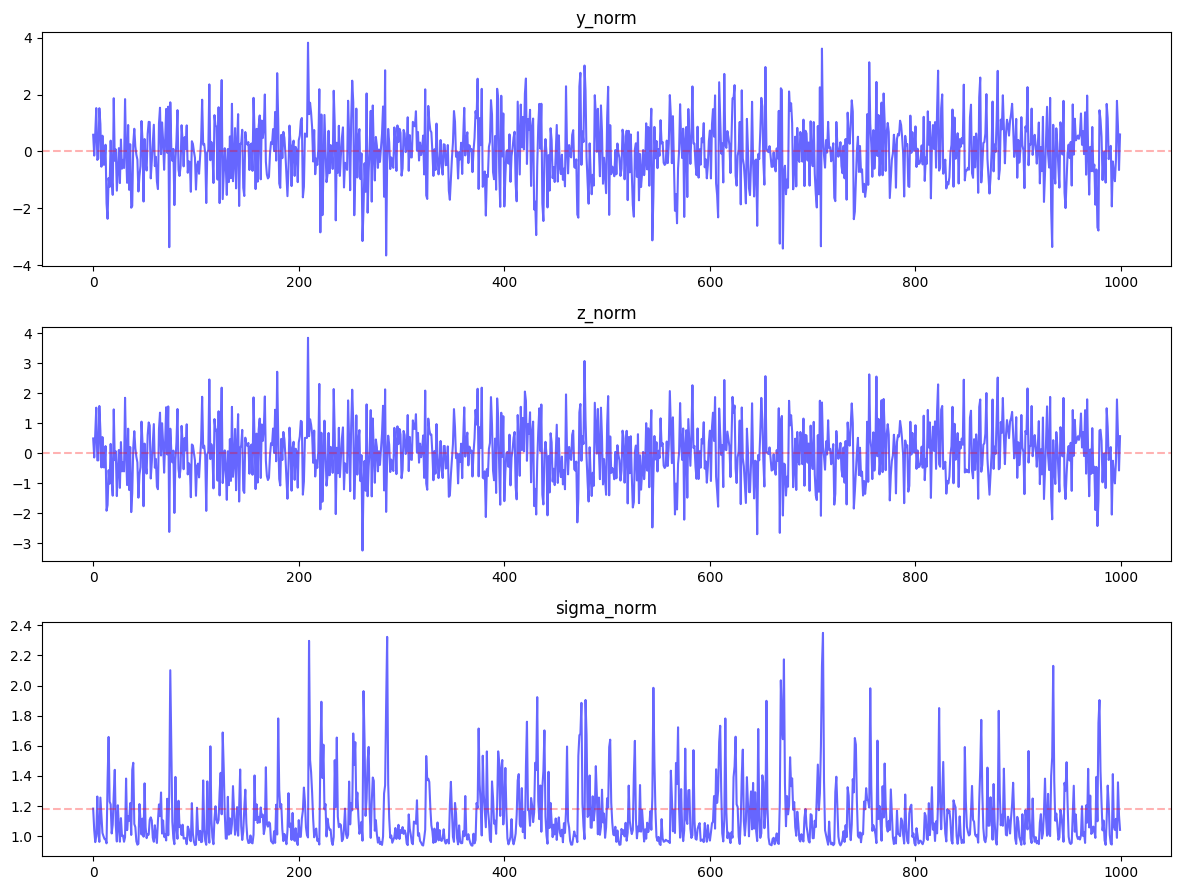

In [4]:
# пример нормального 
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(y_norm, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('y_norm')

axes[1].plot(z_norm, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_title('z_norm')

axes[2].plot(sigma_norm, color='blue', alpha=0.6)
axes[2].axhline(y=uncond_var**0.5, color='red', linestyle='--', alpha=0.3)
axes[2].set_title('sigma_norm')
plt.tight_layout()

plt.show()

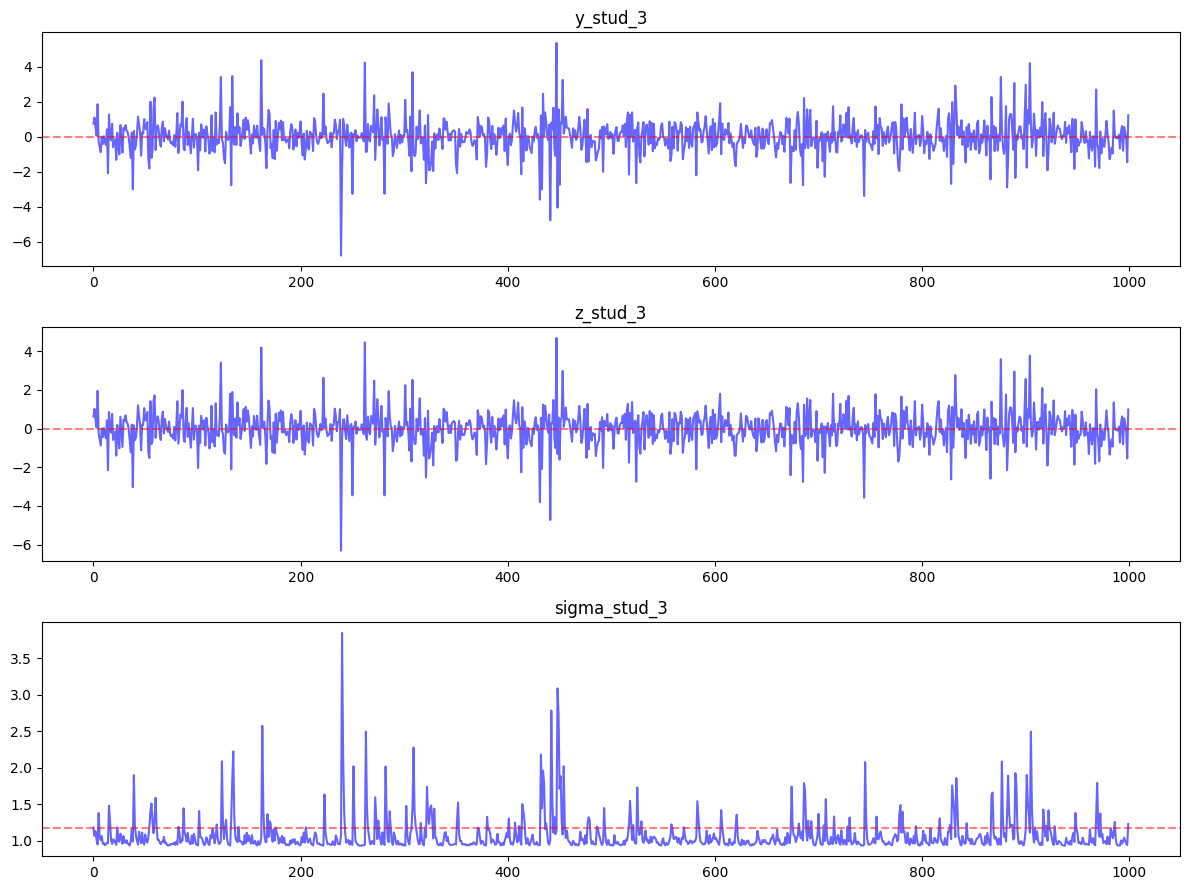

In [5]:
# пример стьюдента 3
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(y_stud_3, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('y_stud_3')

axes[1].plot(z_stud_3, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('z_stud_3')

axes[2].plot(sigma_stud_3, color='blue', alpha=0.6)
axes[2].axhline(y=uncond_var**0.5, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('sigma_stud_3')
plt.tight_layout()

plt.show()

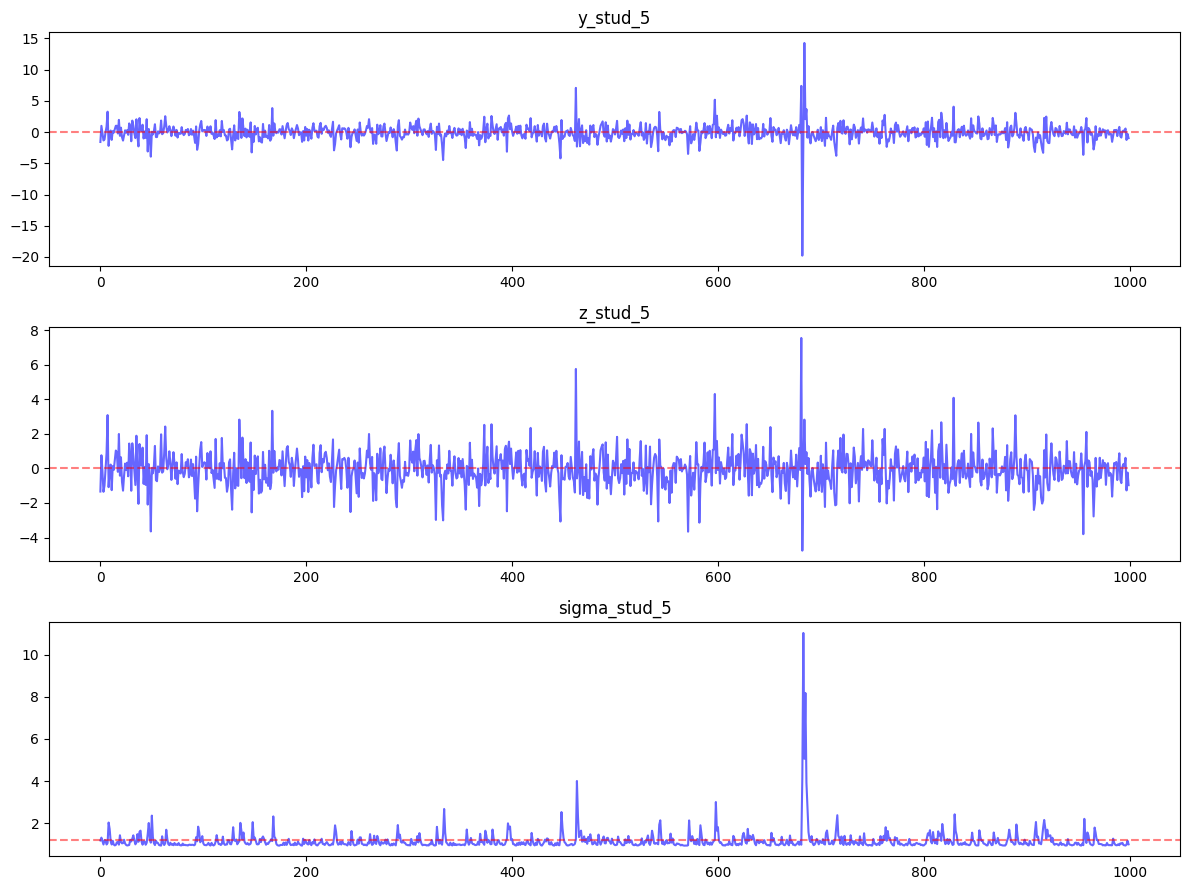

In [6]:
# пример стьюдента 
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(y_stud_5, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('y_stud_5')

axes[1].plot(z_stud_5, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('z_stud_5')

axes[2].plot(sigma_stud_5, color='blue', alpha=0.6)
axes[2].axhline(y=uncond_var**0.5, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('sigma_stud_5')
plt.tight_layout()

plt.show()

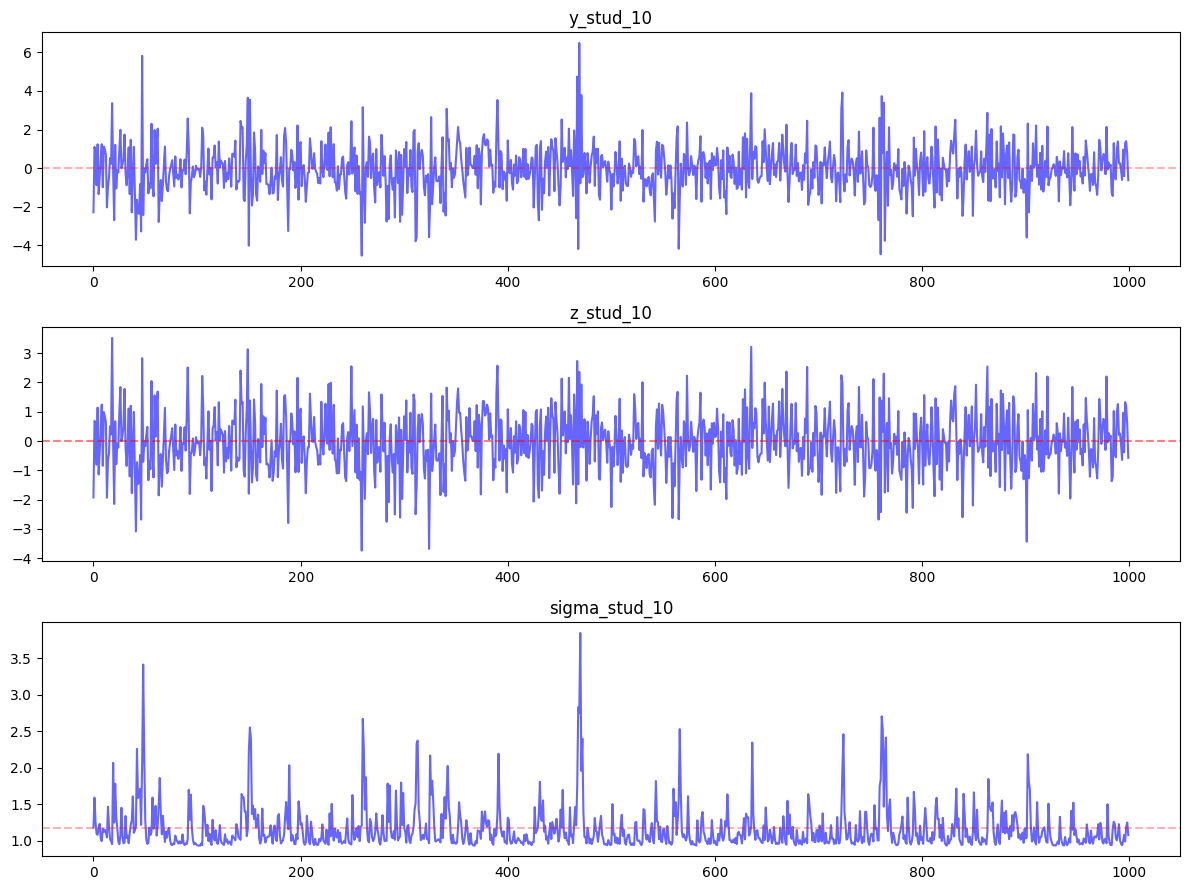

In [7]:
# пример стьюдента 
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(y_stud_10, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('y_stud_10')

axes[1].plot(z_stud_10, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('z_stud_10')

axes[2].plot(sigma_stud_10, color='blue', alpha=0.6)
axes[2].axhline(y=uncond_var**0.5, color='red', linestyle='--', alpha=0.3)
axes[2].set_title('sigma_stud_10')
plt.tight_layout()

plt.show()

## 2. оценки ММП

#### 2.1 оценка ММП на всем

In [8]:
from scipy.optimize import minimize

def estimate_garch11(x): 
    """
    Параметры:
        omega > 0
        alpha >= 0
        beta >= 0
        alpha + beta < 1
    Args:
        x: array-like, одномерный временной ряд
    Returns:
        dict со следующими полями:
            omega: оценка omega
            alpha: оценка alpha
            beta: оценка beta
            loglik: значение лог-правдоподобия в оптимуме
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    var_x = np.var(x)

    def compute_variances(params):
        omega, alpha, beta = params

        h = np.empty(n, dtype=float)

        # Инициализация условной дисперсии
        # Используем безусловную дисперсию, если модель стационарна
        denom = 1.0 - alpha - beta
        if denom <= 0:
            return None

        h0 = omega / denom
        if h0 <= 0 or not np.isfinite(h0):
            return None

        h[0] = h0

        for t in range(1, n):
            h[t] = omega + alpha * x[t - 1] ** 2 + beta * h[t - 1]
            if h[t] <= 0 or not np.isfinite(h[t]):
                return None

        return h

    def neg_loglik(params):
        omega, alpha, beta = params

        # Жёсткие ограничения
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
            return 1e20

        h = compute_variances(params)
        if h is None:
            return 1e20

        # Гауссово лог-правдоподобие
        ll = -0.5 * np.sum(np.log(2.0 * np.pi) + np.log(h) + (x ** 2) / h)

        return -ll

    # Начальные значения
    alpha0 = 0.2
    beta0 = 0.3
    omega0 = var_x * (1.0 - alpha0 - beta0)

    # Подстраховка
    omega0 = max(omega0, 1e-8)

    x0 = np.array([omega0, alpha0, beta0], dtype=float)

    # Границы для L-BFGS-B
    # Ограничение alpha + beta < 1 контролируем в целевой функции
    bounds = [
        (1e-12, None),   # omega > 0
        (0.0, 1.0),      # alpha >= 0
        (0.0, 1.0)       # beta >= 0
    ]

    result = minimize(
        neg_loglik,
        x0,
        method="L-BFGS-B",
        bounds=bounds
    )

    omega_hat, alpha_hat, beta_hat = result.x
    loglik = -result.fun
    sigma_hat = compute_variances((omega_hat, alpha_hat, beta_hat))**0.5

    return {
        "omega": float(omega_hat),
        "alpha": float(alpha_hat),
        "beta": float(beta_hat),
        "loglik": float(loglik),
        "success": bool(result.success),
        "sigmas": sigma_hat
    }

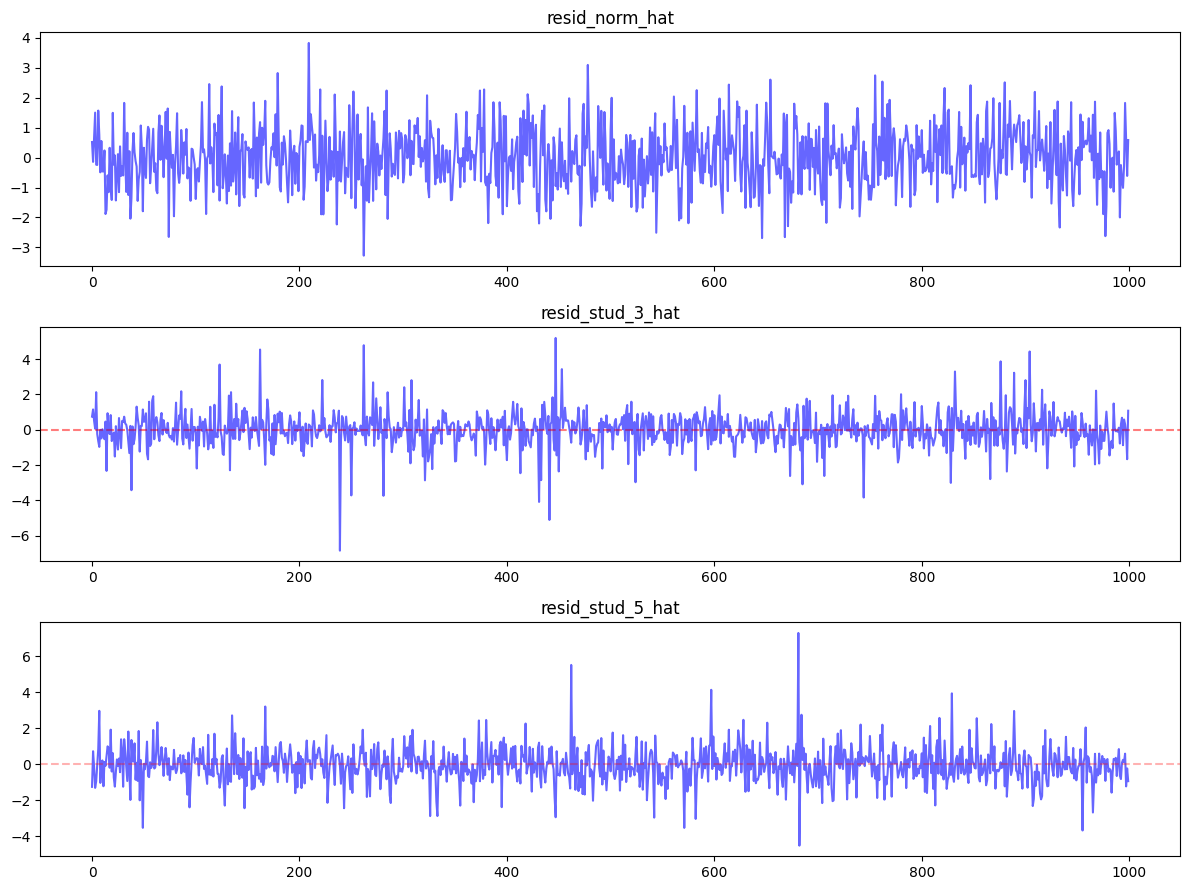

In [9]:
### оценки которые были: 

# N = 1000
# omega = 0.7
# alpha = 0.3
# beta = 0.2

###

resid_norm_hat = y_norm / estimate_garch11(y_norm)['sigmas']
resid_stud_3_hat = y_stud_3 / estimate_garch11(y_stud_3)['sigmas']
resid_stud_5_hat = y_stud_5 / estimate_garch11(y_stud_5)['sigmas']

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(resid_norm_hat, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('resid_norm_hat')

axes[1].plot(resid_stud_3_hat, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_title('resid_stud_3_hat')

axes[2].plot(resid_stud_5_hat, color='blue', alpha=0.6)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[2].set_title('resid_stud_5_hat')

plt.tight_layout()
plt.show()

#### 2.2 ММП оценка скользящим окном 

In [10]:
def rolling_garch_residuals(y, window):
    """
    Оценка остатков GARCH(1,1) скользящим окном.

    Args:
        y: array-like, временной ряд
        window: int, размер окна

    Returns:
        resid: массив остатков той же длины, что y (первые window-1 = NaN)
        h: массив условных дисперсий
    """
    y = np.asarray(y, dtype=float)
    n = len(y)

    resid = np.full(n, np.nan)
    h = np.full(n, np.nan)

    for t in range(window, n + 1):
        # текущее окно
        y_window = y[t - window:t]

        # оцениваем GARCH на окне
        res = estimate_garch11(y_window)

        h_window = res["sigmas"]

        # берем ТОЛЬКО последнюю оценку (one-step-ahead)
        h_t = h_window[-1]**2

        # сохраняем
        h[t - 1] = h_t
        resid[t - 1] = y[t - 1] / h_t

    return resid, h

In [11]:
# оценка скользящим окном

resid_norm_rolling_hat = rolling_garch_residuals(y_norm, 100)[0]
resid_stud_3_rolling_hat = rolling_garch_residuals(y_stud_3, 100)[0]
resid_stud_5_rolling_hat = rolling_garch_residuals(y_stud_5, 100)[0]

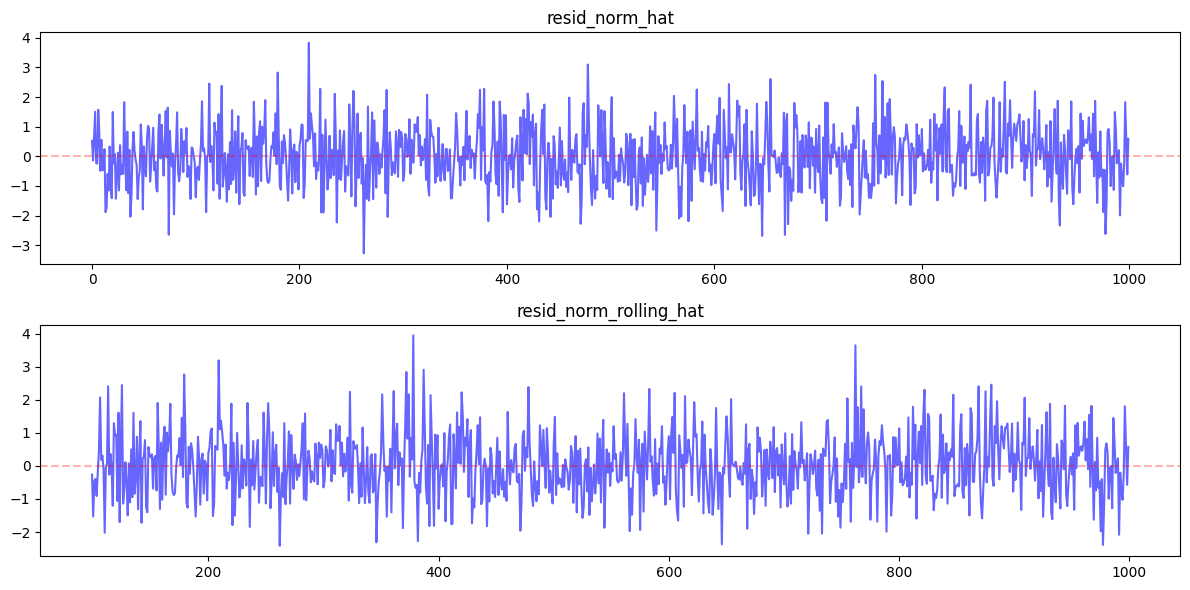

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(resid_norm_hat, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('resid_norm_hat')

axes[1].plot(resid_norm_rolling_hat, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_title('resid_norm_rolling_hat')

plt.tight_layout()
plt.show()

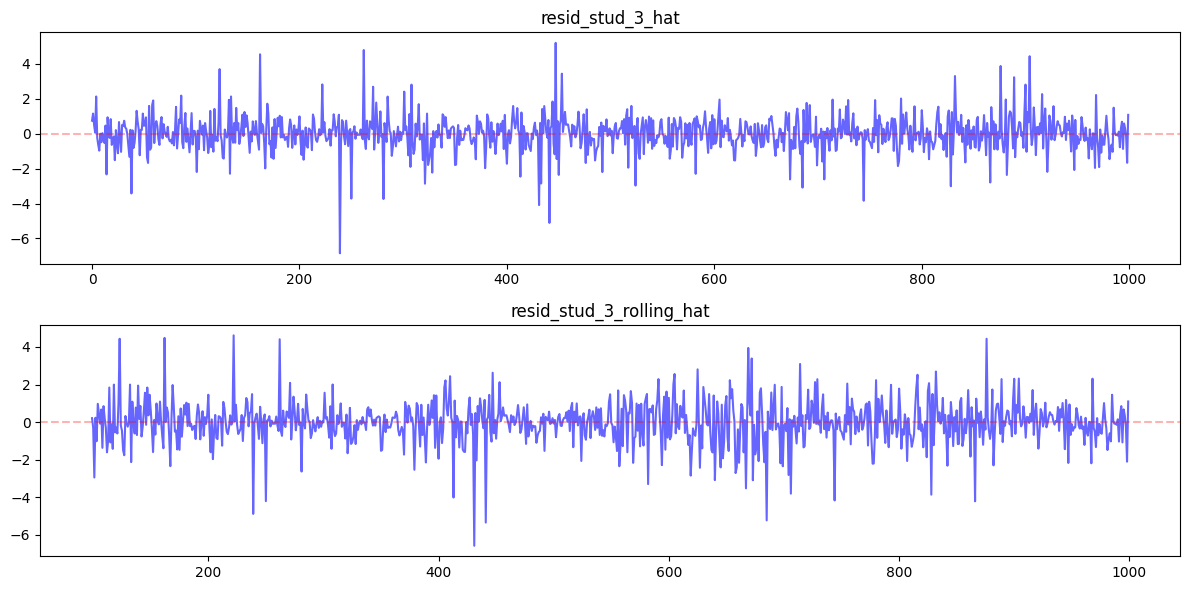

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(resid_stud_3_hat, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('resid_stud_3_hat')

axes[1].plot(resid_stud_3_rolling_hat, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_title('resid_stud_3_rolling_hat')

plt.tight_layout()
plt.show()

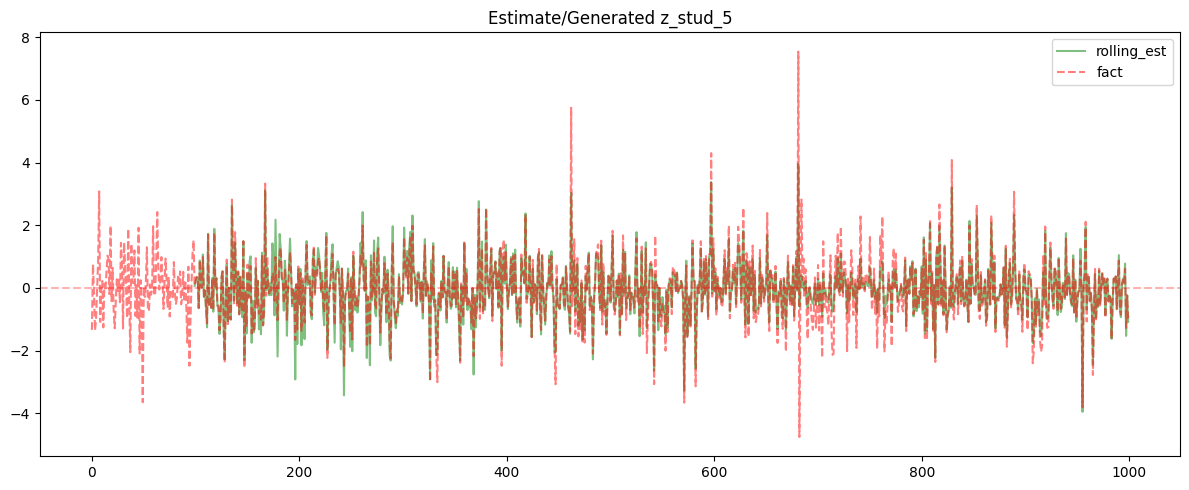

In [14]:
plt.figure(figsize=(12, 5))

# plt.plot(resid_stud_5_hat, color='blue', label='total_est', alpha=0.9)
plt.plot(resid_stud_5_rolling_hat, color='green', label='rolling_est', alpha=0.5)
plt.plot(z_stud_5, color='red', linestyle='--', label='fact', alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.title('Estimate/Generated z_stud_5')
plt.legend()

plt.tight_layout()
plt.show()

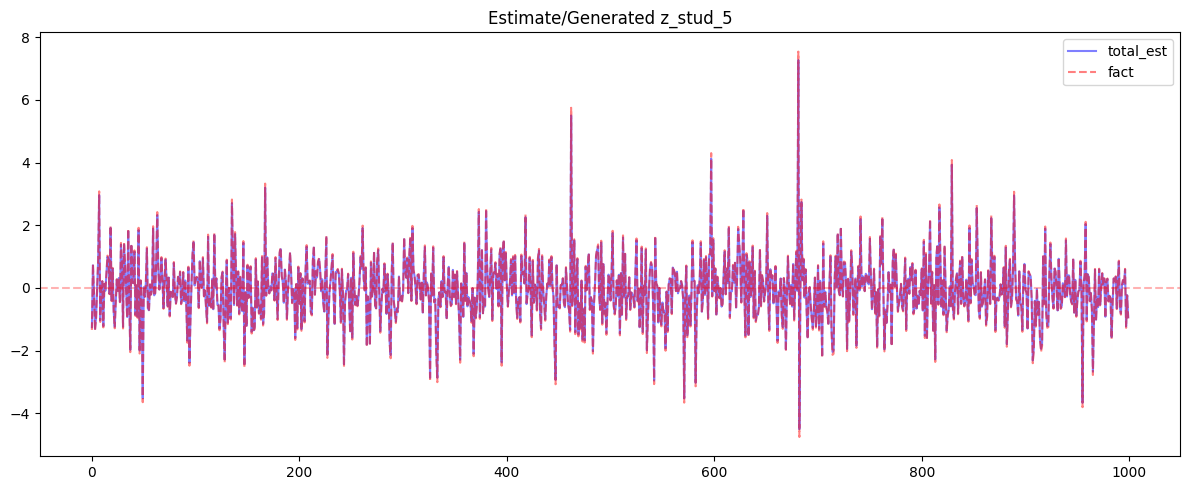

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(resid_stud_5_hat, color='blue', label='total_est', alpha=0.5)
# plt.plot(resid_stud_5_rolling_hat, color='green', label='rolling_est', alpha=0.9)
plt.plot(z_stud_5, color='red', linestyle='--', label='fact', alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.title('Estimate/Generated z_stud_5')
plt.legend()

plt.tight_layout()
plt.show()

#### 3. POT + GPD


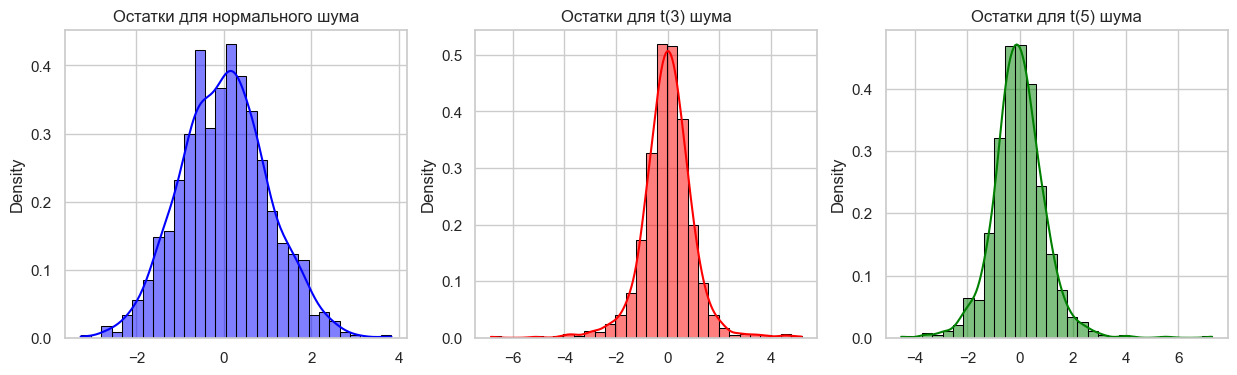

In [16]:
sns.set(style="whitegrid")

# Создаем 1 строку и 3 столбца графиков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Первый график
sns.histplot(resid_norm_hat, bins=30, kde=True, color='blue',
             edgecolor='black', stat='density', ax=axes[0])
axes[0].set_title("Остатки для нормального шума")

# Второй график
sns.histplot(resid_stud_3_hat, bins=30, kde=True, color='red',
             edgecolor='black', stat='density', ax=axes[1])
axes[1].set_title("Остатки для t(3) шума")

# Третий график
sns.histplot(resid_stud_5_hat, bins=30, kde=True, color='green',
             edgecolor='black', stat='density', ax=axes[2])
axes[2].set_title("Остатки для t(5) шума")

plt.show()

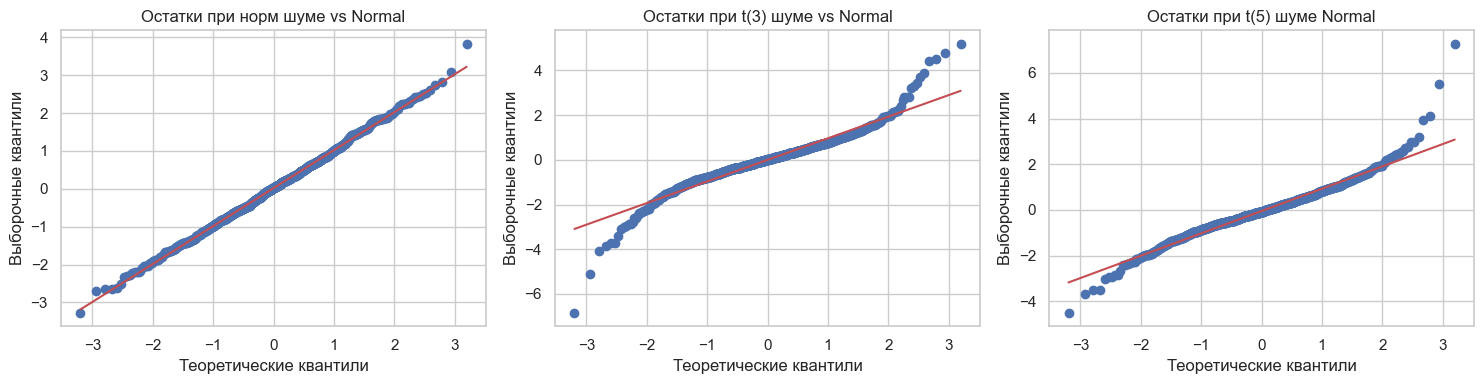

In [17]:
import scipy.stats as stats

# для классичесикх оценок

# Создаем 1 строку и 3 графика
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Первый Q-Q plot
stats.probplot(resid_norm_hat, dist="norm", plot=axes[0])
axes[0].set_title("Остатки при норм шуме vs Normal")

# Второй Q-Q plot
stats.probplot(resid_stud_3_hat, dist="norm", plot=axes[1])
axes[1].set_title("Остатки при t(3) шуме vs Normal")

# Третий Q-Q plot
stats.probplot(resid_stud_5_hat, dist="norm", plot=axes[2])
axes[2].set_title("Остатки при t(5) шуме Normal")

# Общая настройка (по желанию)
for ax in axes:
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Выборочные квантили")

plt.tight_layout()
plt.show()

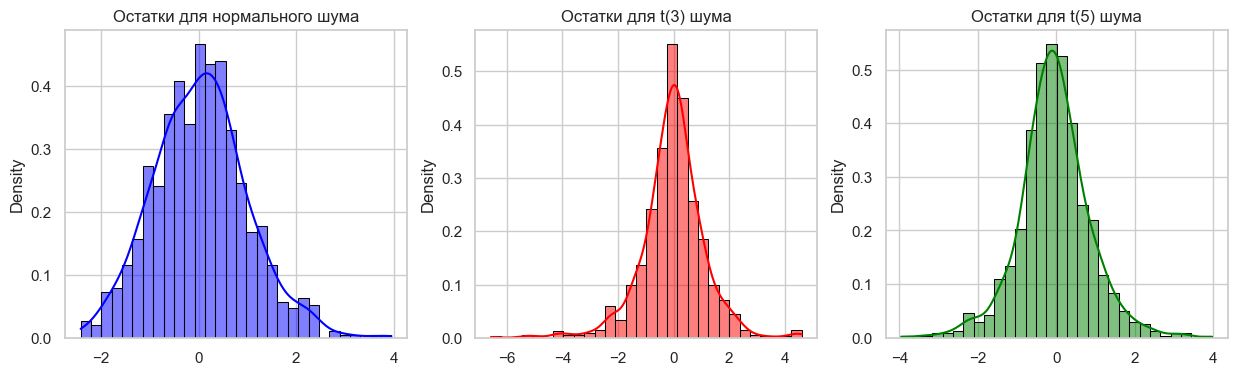

In [18]:
sns.set(style="whitegrid")

# Создаем 1 строку и 3 столбца графиков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Первый график
sns.histplot(resid_norm_rolling_hat, bins=30, kde=True, color='blue',
             edgecolor='black', stat='density', ax=axes[0])
axes[0].set_title("Остатки для нормального шума")

# Второй график
sns.histplot(resid_stud_3_rolling_hat, bins=30, kde=True, color='red',
             edgecolor='black', stat='density', ax=axes[1])
axes[1].set_title("Остатки для t(3) шума")

# Третий график
sns.histplot(resid_stud_5_rolling_hat, bins=30, kde=True, color='green',
             edgecolor='black', stat='density', ax=axes[2])
axes[2].set_title("Остатки для t(5) шума")

plt.show()

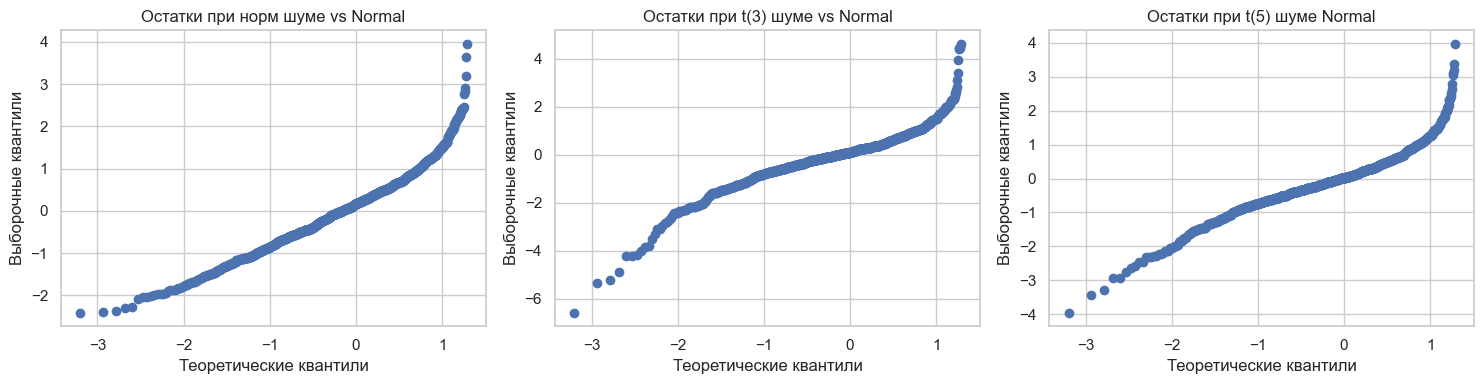

In [19]:
import scipy.stats as stats

# для классичесикх оценок

# Создаем 1 строку и 3 графика
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Первый Q-Q plot
stats.probplot(resid_norm_rolling_hat, dist="norm", plot=axes[0])
axes[0].set_title("Остатки при норм шуме vs Normal")

# Второй Q-Q plot
stats.probplot(resid_stud_3_rolling_hat, dist="norm", plot=axes[1])
axes[1].set_title("Остатки при t(3) шуме vs Normal")

# Третий Q-Q plot
stats.probplot(resid_stud_5_rolling_hat, dist="norm", plot=axes[2])
axes[2].set_title("Остатки при t(5) шуме Normal")

# Общая настройка (по желанию)
for ax in axes:
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Выборочные квантили")

plt.tight_layout()
plt.show()

%% [markdown]
## Генерация AR(1) последовательности

$X_t = \rho * X_{t-1} + \sqrt{1 - \rho^2} * Z_t$, 

где $Z_t \sim N(0,1)$

Тогда $X_t \sim N(0,1)$ и $\gamma(k) = Cov(X_0, X_k) = \rho^k$



Условие Бермана: $\gamma(n) * ln(n) = \rho^n * ln(n) -> 0$

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def generate_ar1(n, rho):
    sigma = np.sqrt(1 - rho**2)
    x = np.zeros(n)
    x[0] = np.random.randn()
    for t in range(1, n):
        x[t] = rho * x[t-1] + sigma * np.random.randn()
    return x

# нормирующие константы из теоремы
def c_n(n):
    return np.sqrt(2 * np.log(n)) - (np.log(np.log(n)) + np.log(4 * np.pi)) / (2 * np.sqrt(2 * np.log(n)))

def d_n(n):
    return np.sqrt(2 * np.log(n))

# одна реализация нормированного максимума
def normalised_max(n, rho):
    x = generate_ar1(n, rho)
    M = np.max(x)
    return d_n(n) * (M - c_n(n))

In [33]:
n = 2000      # длина последовательности
rho = 0.5
n_rep = 3000  # число реплик

samples = np.array([normalised_max(n, rho) for _ in range(n_rep)])

print(f"Среднее:    {samples.mean():.4f}  (теор. {stats.gumbel_r.mean(0, 1):.4f})")
print(f"Дисперсия:  {samples.var():.4f}  (теор. {stats.gumbel_r.var(0, 1):.4f})")

Среднее:    0.4177  (теор. 0.5772)
Дисперсия:  1.7627  (теор. 1.6449)


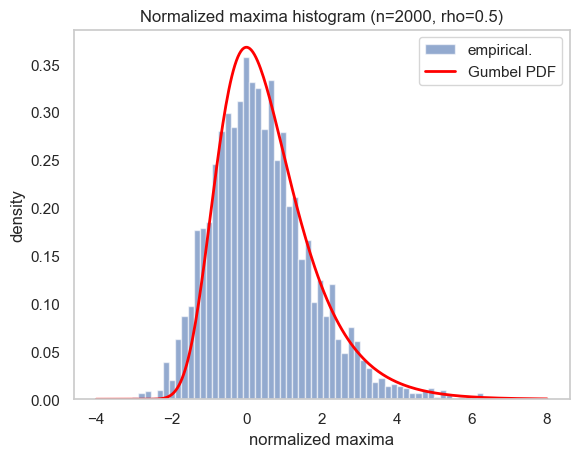

In [35]:
x = np.linspace(-4, 8, 300)

plt.hist(samples, bins=60, density=True, alpha=0.6, label="empirical.")
plt.plot(x, stats.gumbel_r.pdf(x), color="red", lw=2, label="Gumbel PDF")
plt.xlabel("normalized maxima")
plt.ylabel("density")
plt.title(f"Normalized maxima histogram (n={n}, rho={rho})")
plt.legend()
plt.grid()
plt.show()

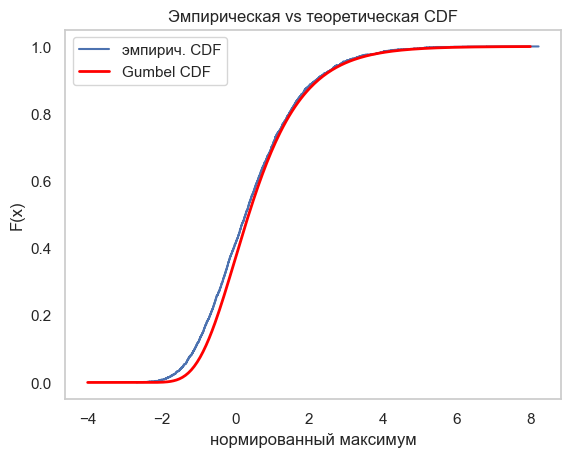

In [23]:
# ## Эмпирическая CDF vs теоретическая

# %%
sorted_s = np.sort(samples)
ecdf = np.arange(1, n_rep + 1) / n_rep

plt.step(sorted_s, ecdf, label="эмпирич. CDF")
plt.plot(x, stats.gumbel_r.cdf(x), color="red", lw=2, label="Gumbel CDF")
plt.xlabel("нормированный максимум")
plt.ylabel("F(x)")
plt.title("Эмпирическая vs теоретическая CDF")
plt.legend()
plt.grid()
plt.show()

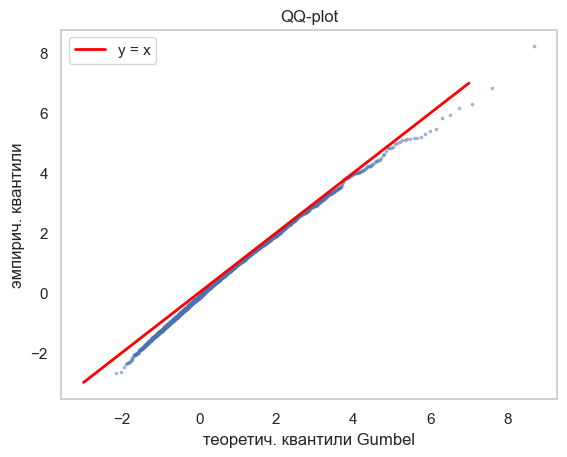

In [24]:
probs = (np.arange(1, n_rep + 1) - 0.5) / n_rep
theor_quantiles = stats.gumbel_r.ppf(probs)

plt.scatter(theor_quantiles, sorted_s, s=3, alpha=0.4)
plt.plot([-3, 7], [-3, 7], color="red", lw=2, label="y = x")
plt.xlabel("теоретич. квантили Gumbel")
plt.ylabel("эмпирич. квантили")
plt.title("QQ-plot")
plt.legend()
plt.grid()
plt.show()

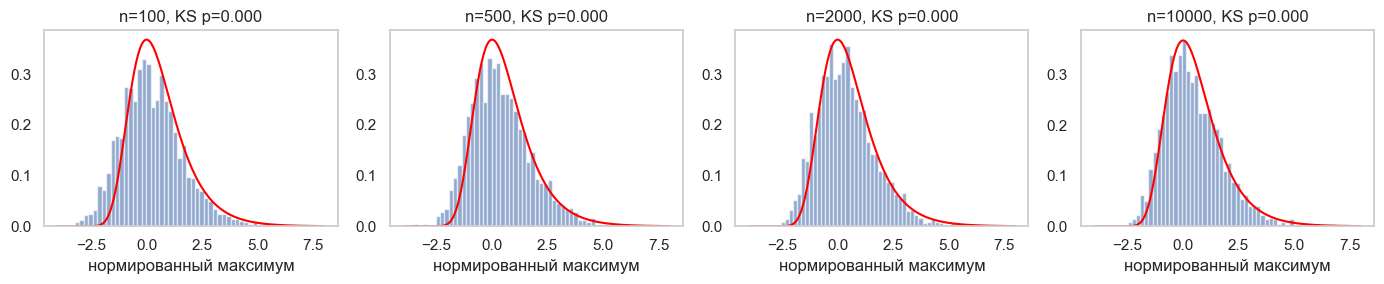

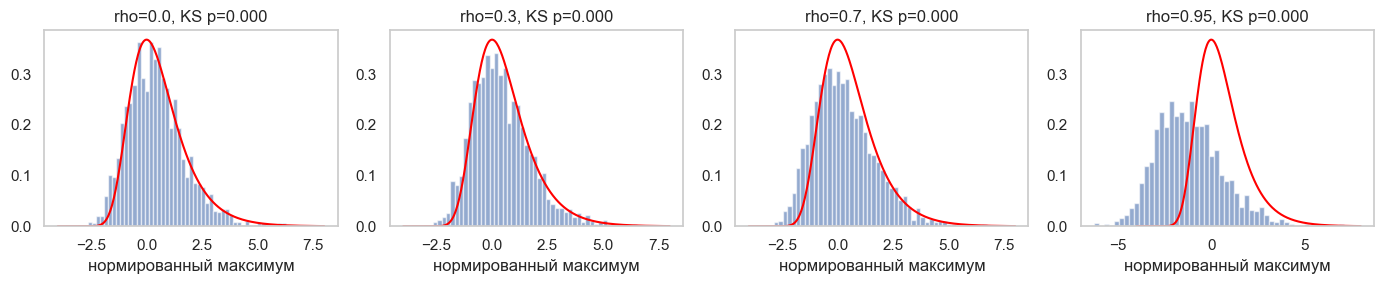

In [25]:
# ## Как меняется сходимость при разных n

# %%
n_values = [100, 500, 2000, 10000]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, n_val in zip(axes, n_values):
    samp = np.array([normalised_max(n_val, rho) for _ in range(2000)])
    ax.hist(samp, bins=50, density=True, alpha=0.6)
    ax.plot(x, stats.gumbel_r.pdf(x), color="red", lw=1.5)
    ks, p = stats.kstest(samp, stats.gumbel_r.cdf)
    ax.set_title(f"n={n_val}, KS p={p:.3f}")
    ax.set_xlabel("нормированный максимум")
    ax.grid()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Как меняется сходимость при разных rho

# %%
rho_values = [0.0, 0.3, 0.7, 0.95]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, rho_val in zip(axes, rho_values):
    samp = np.array([normalised_max(1000, rho_val) for _ in range(2000)])
    ax.hist(samp, bins=50, density=True, alpha=0.6)
    ax.plot(x, stats.gumbel_r.pdf(x), color="red", lw=1.5)
    ks, p = stats.kstest(samp, stats.gumbel_r.cdf)
    ax.set_title(f"rho={rho_val}, KS p={p:.3f}")
    ax.set_xlabel("нормированный максимум")
    ax.grid()

plt.tight_layout()
plt.show()

## GARCH VS GARCH-EVA(1,1) VS GARCH-EVT GPD(1,1) VS fitting GEV

In [ ]:
# summarize: 

# garch_11_norm_sample: 
# estimate_garch11 —- оценка GARCH(1,1)

In [ ]:
# хочу написать код, который скользящим окном оценивает нижний квантиль распределения

In [48]:
## GARCH(1,1)
from scipy.stats import norm

"""
Оценка остатков GARCH(1,1) скользящим окном.

Args:
    y: array-like, временной ряд
    window: int, размер окна

Returns:
    resid: массив остатков той же длины, что y (первые window-1 = NaN)
    h: массив условных дисперсий
"""

y = y_norm
window = 100
alpha = 0.01

quantile = norm.ppf(alpha)

y = np.asarray(y, dtype=float)
n = len(y)

resid = np.full(n, np.nan)
h = np.full(n, np.nan) 
r_quantile = np.full(n + 1, np.nan) # сюда сложу квантили условного распределения на шаг t + 1

for t in range(window, n + 1): # в этот цикл хочу вставить подсчет след 
    # текущее окно -- обрабатываем отрезок от 
    y_window = y[t - window:t] # от 0 до window, от 1 до window + 1, от 2 до window + 2, ...

    # оцениваем GARCH на окне
    res = estimate_garch11(y_window)

    h_window = res["sigmas"] 
    omega_window = res['omega']
    alpha_window = res['alpha']
    beta_window = res['beta']

    # берем ТОЛЬКО последнюю оценку (one-step-ahead)
    h_t = h_window[-1]**2 # берем последнее число в массиве sigma2

    # вычисляем прогноз волатильности на след шаг
    sigma_t_plus1 = (omega_window + alpha * y[t-1] + beta * h_t)**0.5

    # сохраняем
    h[t - 1] = h_t
    resid[t - 1] = y[t - 1] / h_t
    r_quantile[t] = quantile * sigma_t_plus1


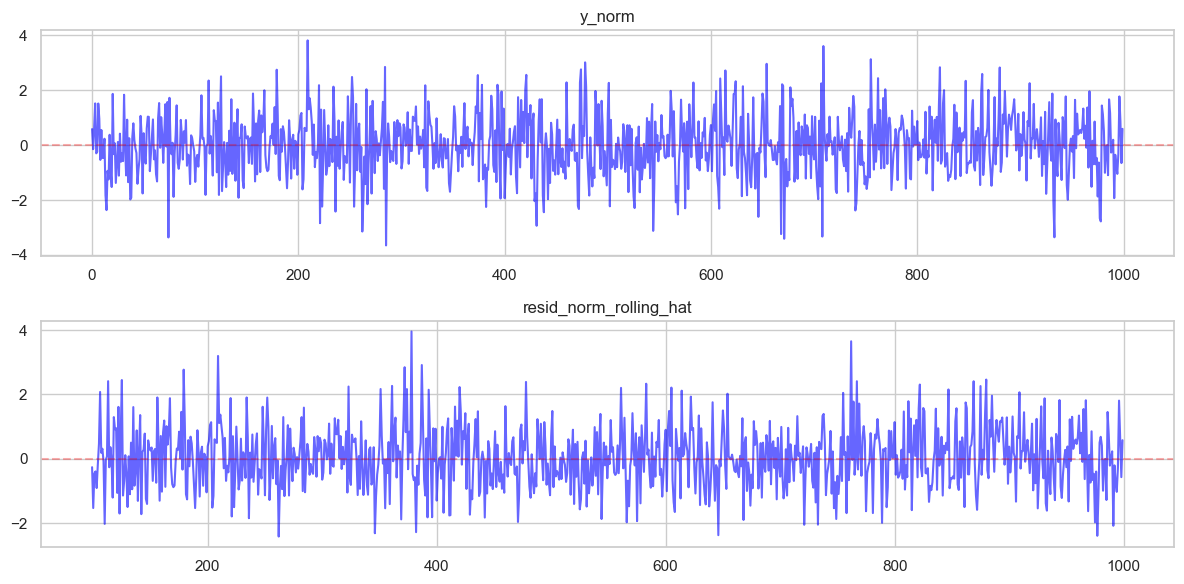

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(y_norm, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('y_norm')

axes[1].plot(y, color='blue', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_title('resid_norm_rolling_hat')

plt.tight_layout()
plt.show()